# Лабораторная работа №6

**Тема:** ансамбли моделей машинного обучения. Часть 2.

**Цель работы:** изучить ансамблевые модели машинного обучения, модель стекинга и многослойный персептрон.

**Датасеты:** `lr3/pokemon_complete.csv`, `lr3/pokemon_types.csv`.


## Описание задания

В работе решается задача регрессии: необходимо спрогнозировать базовый опыт Pokémon `base_experience` по его характеристикам, физическим параметрам, редкости, поколению, типам и признакам взаимодействия типов.

Для сравнения используются две модели:

- `StackingRegressor` — ансамблевая модель группы стекинга;
- `MLPRegressor` — многослойный персептрон из библиотеки `scikit-learn`.

Качество моделей оценивается по метрике `MAE`. Чем меньше значение `MAE`, тем точнее модель предсказывает базовый опыт Pokémon.

Дополнительная часть с методами МГУА в этой работе не выполняется, так как она является необязательной и требует отдельной библиотеки `gmdh`.


## Импорт библиотек


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

%matplotlib inline
plt.style.use('default')
RANDOM_STATE = 42


## Загрузка данных


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'lr3' / 'pokemon_complete.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

pokemon_df = pd.read_csv(PROJECT_ROOT / 'lr3' / 'pokemon_complete.csv')
types_df = pd.read_csv(PROJECT_ROOT / 'lr3' / 'pokemon_types.csv')

print('Размер основной таблицы:', pokemon_df.shape)
print('Размер таблицы типов:', types_df.shape)
display(pokemon_df.head())
display(types_df.head())


Размер основной таблицы: (1350, 31)
Размер таблицы типов: (18, 7)


,pokedex_number,name,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,...,shape,egg_groups,habitat,growth_rate,capture_rate,base_happiness,genus,evolution_chain_id,flavor_text,sprite_url
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,A strange seed was planted on its back at birt...,https://raw.githubusercontent.com/PokeAPI/spri...
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,"When the bulb on its back grows large, it appe...",https://raw.githubusercontent.com/PokeAPI/spri...
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,The plant blooms when it is absorbing solar en...,https://raw.githubusercontent.com/PokeAPI/spri...
3,4,Charmander,Fire,NaN,39,52,43,60,50,65,...,upright,monster|dragon,mountain,medium-slow,45,70,Lizard Pokémon,2,"Obviously prefers hot places. When it rains, s...",https://raw.githubusercontent.com/PokeAPI/spri...
4,5,Charmeleon,Fire,NaN,58,64,58,80,65,80,...,upright,monster|dragon,mountain,medium-slow,45,70,Flame Pokémon,2,"When it swings its burning tail, it elevates t...",https://raw.githubusercontent.com/PokeAPI/spri...


,type,double_damage_to,half_damage_to,no_damage_to,double_damage_from,half_damage_from,no_damage_from
0,normal,NaN,rock|steel,ghost,fighting,NaN,ghost
1,fighting,normal|rock|steel|ice|dark,flying|poison|bug|psychic|fairy,ghost,flying|psychic|fairy,rock|bug|dark,NaN
2,flying,fighting|bug|grass,rock|steel|electric,NaN,rock|electric|ice,fighting|bug|grass,ground
3,poison,grass|fairy,poison|ground|rock|ghost,steel,ground|psychic,fighting|poison|bug|grass|fairy,NaN
4,ground,poison|rock|steel|fire|electric,bug|grass,flying,water|grass|ice,poison|rock,electric


## Предобработка данных

Строки с пропущенным целевым признаком `base_experience` удаляются. Остальные пропуски обрабатываются в пайплайне: числовые признаки заполняются медианой, категориальные — самым частым значением. Категориальные признаки кодируются с помощью one-hot encoding.

Дополнительная таблица `pokemon_types.csv` используется для формирования числовых признаков по взаимодействиям типов: количество типов с двойным, половинным или нулевым уроном.


In [3]:
missing_summary = pokemon_df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


habitat            830
type_2             585
hidden_ability     362
sprite_url          60
base_experience     48
abilities           25
dtype: int64

In [4]:
def count_type_list(value):
    """Считает количество типов в строке вида 'fire|water'."""
    if pd.isna(value) or value == '':
        return 0
    return len(str(value).split('|'))

interaction_columns = [
    'double_damage_to',
    'half_damage_to',
    'no_damage_to',
    'double_damage_from',
    'half_damage_from',
    'no_damage_from',
]

type_features = types_df.copy()
type_features['type'] = type_features['type'].str.lower()

for column in interaction_columns:
    type_features[f'{column}_count'] = type_features[column].apply(count_type_list)

type_features = type_features[['type'] + [f'{column}_count' for column in interaction_columns]]
type_features.head()


,type,double_damage_to_count,half_damage_to_count,no_damage_to_count,double_damage_from_count,half_damage_from_count,no_damage_from_count
0,normal,0,2,1,1,0,1
1,fighting,5,5,1,3,3,0
2,flying,3,3,0,3,3,1
3,poison,2,4,1,2,5,0
4,ground,5,2,1,3,2,1


In [5]:
primary_type_features = type_features.add_prefix('type_1_').rename(columns={'type_1_type': 'type_1_key'})
secondary_type_features = type_features.add_prefix('type_2_').rename(columns={'type_2_type': 'type_2_key'})

data = pokemon_df.copy()
data['type_1_key'] = data['type_1'].str.lower()
data['type_2_key'] = data['type_2'].str.lower()

data = data.merge(primary_type_features, on='type_1_key', how='left')
data = data.merge(secondary_type_features, on='type_2_key', how='left')

type_count_columns = [column for column in data.columns if column.endswith('_count')]
data[type_count_columns] = data[type_count_columns].fillna(0)

data[type_count_columns].head()


,type_1_double_damage_to_count,type_1_half_damage_to_count,type_1_no_damage_to_count,type_1_double_damage_from_count,type_1_half_damage_from_count,type_1_no_damage_from_count,type_2_double_damage_to_count,type_2_half_damage_to_count,type_2_no_damage_to_count,type_2_double_damage_from_count,type_2_half_damage_from_count,type_2_no_damage_from_count
0,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
1,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
2,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
3,4,4,0,3,6,0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,4,0,3,6,0,0.0,0.0,0.0,0.0,0.0,0.0


## Формирование обучающей и тестовой выборки


In [6]:
target = 'base_experience'

feature_columns = [
    'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed',
    'base_stat_total', 'height_m', 'weight_kg', 'capture_rate', 'base_happiness',
    'generation', 'is_legendary', 'is_mythical', 'is_baby',
    'type_1', 'type_2', 'color', 'shape', 'habitat', 'growth_rate',
] + type_count_columns

model_df = data[feature_columns + [target]].dropna(subset=[target]).copy()

bool_columns = model_df.select_dtypes(include=['bool']).columns.tolist()
model_df[bool_columns] = model_df[bool_columns].astype(int)

X = model_df[feature_columns]
y = model_df[target]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Размер X:', X.shape)
print('Размер y:', y.shape)
print('Числовых признаков:', len(numeric_features))
print('Категориальных признаков:', len(categorical_features))


Размер X: (1302, 33)
Размер y: (1302,)
Числовых признаков: 26
Категориальных признаков: 7


C:\Users\Den\AppData\Local\Temp\ipykernel_11672\3222041618.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка:', X_test.shape)


Обучающая выборка: (976, 33)
Тестовая выборка: (326, 33)


In [8]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])


## Обучение моделей


In [9]:
stacking_model = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(
            n_estimators=60,
            max_depth=8,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
        ('extra', ExtraTreesRegressor(
            n_estimators=60,
            max_depth=8,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
        ('gb', GradientBoostingRegressor(
            n_estimators=80,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
        )),
    ],
    final_estimator=RidgeCV(),
    cv=3,
    n_jobs=1,
)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=1500,
    early_stopping=True,
    random_state=RANDOM_STATE,
)

models = {
    'Stacking Regressor': stacking_model,
    'MLP Regressor': mlp_model,
}

trained_models = {}
rows = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    trained_models[model_name] = pipeline
    rows.append({
        'model': model_name,
        'MAE': mean_absolute_error(y_test, predictions),
    })

metrics_df = pd.DataFrame(rows).sort_values('MAE')
metrics_df


,model,MAE
0,Stacking Regressor,13.019504
1,MLP Regressor,17.701681


## Сравнение качества моделей


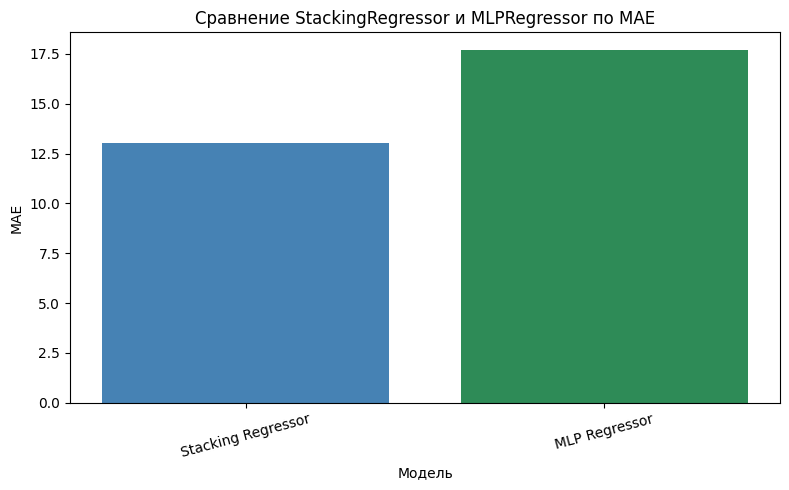

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(metrics_df['model'], metrics_df['MAE'], color=['steelblue', 'seagreen'])
plt.title('Сравнение StackingRegressor и MLPRegressor по MAE')
plt.xlabel('Модель')
plt.ylabel('MAE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [11]:
best_model_name = metrics_df.iloc[0]['model']
print('Лучшая модель по MAE:', best_model_name)
metrics_df


Лучшая модель по MAE: Stacking Regressor


,model,MAE
0,Stacking Regressor,13.019504
1,MLP Regressor,17.701681


## Анализ предсказаний лучшей модели


In [12]:
best_pipeline = trained_models[best_model_name]
best_predictions = best_pipeline.predict(X_test)

prediction_examples = pd.DataFrame({
    'true_base_experience': y_test.values,
    'predicted_base_experience': best_predictions,
    'absolute_error': np.abs(y_test.values - best_predictions),
}).sort_values('absolute_error')

prediction_examples.head(10)


,true_base_experience,predicted_base_experience,absolute_error
73,151.0,150.959713,0.040287
234,51.0,50.834946,0.165054
99,54.0,53.802145,0.197855
91,175.0,175.255045,0.255045
208,159.0,159.328495,0.328495
255,56.0,55.655841,0.344159
40,61.0,61.419768,0.419768
173,147.0,146.551936,0.448064
288,144.0,144.476297,0.476297
214,147.0,147.478751,0.478751


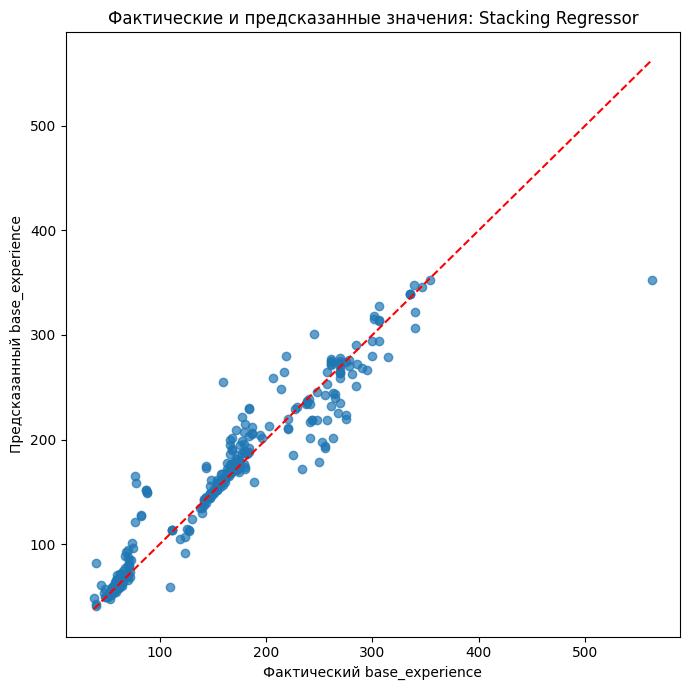

In [13]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.7)
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--')
plt.title(f'Фактические и предсказанные значения: {best_model_name}')
plt.xlabel('Фактический base_experience')
plt.ylabel('Предсказанный base_experience')
plt.tight_layout()
plt.show()


## Вывод

В ходе лабораторной работы были подготовлены данные о Pokémon, выполнено заполнение пропусков и кодирование категориальных признаков. Выборка была разделена на обучающую и тестовую с помощью `train_test_split`.

Были обучены две модели: стекинг-регрессор и многослойный персептрон. По метрике `MAE` можно сравнить среднюю абсолютную ошибку моделей и выбрать лучший вариант для предсказания `base_experience`. Дополнительно для лучшей модели построен график соответствия фактических и предсказанных значений.
